# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
import pandas as pd
import time
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import urllib.request
import sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
response = urllib.request.urlopen(url)
raw_text = response.read().decode('utf-8')

corpus_lines = [line.strip() for line in raw_text.split('\n') if len(line.strip()) > 10]
corpus = "\n".join(corpus_lines[:800])

print("Total lines loaded:", len(corpus_lines[:800]))

Total lines loaded: 800


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 1543
X shape: (4825, 11)
y shape: (4825,)


In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training samples :", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples : 3860
Validation samples: 965


In [5]:
checkpoint_rnn_base = ModelCheckpoint("best_rnn.keras", monitor="val_loss", save_best_only=True, verbose=1)
checkpoint_rnn_upgraded = ModelCheckpoint("best_rnn_upgraded.keras", monitor="val_loss", save_best_only=True, verbose=1)

checkpoint_lstm_base = ModelCheckpoint("best_lstm.keras", monitor="val_loss", save_best_only=True, verbose=1)
checkpoint_lstm_upgraded = ModelCheckpoint("best_lstm_upgraded.keras", monitor="val_loss", save_best_only=True, verbose=1)

checkpoint_gru_base = ModelCheckpoint("best_gru.keras", monitor="val_loss", save_best_only=True, verbose=1)
checkpoint_gru_upgraded = ModelCheckpoint("best_gru_upgraded.keras", monitor="val_loss", save_best_only=True, verbose=1)

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [6]:
rnn_baseline = Sequential([
    Embedding(total_words, 32),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_baseline.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_rnn_base = rnn_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop, checkpoint_rnn_base],
    verbose=1
)

training_time = time.time() - start_time
rnn_base_training_time = training_time

print("Vanilla RNN Baseline training completed")
print(f"Training Time: {rnn_base_training_time:.2f} seconds")
print(f"Final Training Loss: {history_rnn_base.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_rnn_base.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_rnn_base.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_rnn_base.history['val_accuracy'][-1]:.4f}")

Epoch 1/100
113/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0318 - loss: 6.7263
Epoch 1: val_loss improved from None to 6.63464, saving model to best_rnn.keras

Epoch 1: finished saving model to best_rnn.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0332 - loss: 6.7151 - val_accuracy: 0.0456 - val_loss: 6.6346
Epoch 2/100
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0414 - loss: 6.2245
Epoch 2: val_loss did not improve from 6.63464
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0412 - loss: 6.2260 - val_accuracy: 0.0456 - val_loss: 6.7689
Epoch 3/100
111/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0403 - loss: 6.1194
Epoch 3: val_loss did not improve from 6.63464
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0412 - loss: 6.1242 - val_accuracy: 0.0456 - val_loss: 6.7602
Epoch 4/100
109/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0433 - loss: 6.0084
Epoch 4: val_loss did not improve from 6.63464
121/121 ━━━━━━━━━━━━━━━━━━━━ 1

In [7]:
rnn_upgraded = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_upgraded.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_rnn_upgraded = rnn_upgraded.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop, checkpoint_rnn_upgraded],
    verbose=1
)

training_time = time.time() - start_time
rnn_upgraded_training_time = training_time

print("Vanilla RNN Upgraded training completed")
print(f"Training Time: {rnn_upgraded_training_time:.2f} seconds")
print(f"Final Training Loss: {history_rnn_upgraded.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_rnn_upgraded.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_rnn_upgraded.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_rnn_upgraded.history['val_accuracy'][-1]:.4f}")

Epoch 1/100
115/121 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0375 - loss: 6.6768
Epoch 1: val_loss improved from None to 6.65197, saving model to best_rnn_upgraded.keras

Epoch 1: finished saving model to best_rnn_upgraded.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0368 - loss: 6.6781 - val_accuracy: 0.0456 - val_loss: 6.6520
Epoch 2/100
111/121 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0377 - loss: 6.2141
Epoch 2: val_loss did not improve from 6.65197
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0396 - loss: 6.2045 - val_accuracy: 0.0456 - val_loss: 6.7989
Epoch 3/100
118/121 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0456 - loss: 6.0213
Epoch 3: val_loss did not improve from 6.65197
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0453 - loss: 6.0179 - val_accuracy: 0.0466 - val_loss: 6.8257
Epoch 4/100
116/121 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0552 - loss: 5.7823
Epoch 4: val_loss did not improve from 6.65197
121/121 ━━━━

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [8]:
lstm_baseline = Sequential([
    Embedding(total_words, 32),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_baseline.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_lstm_base = lstm_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop, checkpoint_lstm_base],
    verbose=1
)

training_time = time.time() - start_time
lstm_base_training_time = training_time

print("LSTM Baseline training completed")
print(f"Training Time: {lstm_base_training_time:.2f} seconds")
print(f"Final Training Loss: {history_lstm_base.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_lstm_base.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_lstm_base.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_lstm_base.history['val_accuracy'][-1]:.4f}")

Epoch 1/100
117/121 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0275 - loss: 6.7660
Epoch 1: val_loss improved from None to 6.61067, saving model to best_lstm.keras

Epoch 1: finished saving model to best_lstm.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0293 - loss: 6.7623 - val_accuracy: 0.0456 - val_loss: 6.6107
Epoch 2/100
114/121 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0400 - loss: 6.2199
Epoch 2: val_loss did not improve from 6.61067
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0412 - loss: 6.2231 - val_accuracy: 0.0456 - val_loss: 6.7458
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0412 - loss: 6.1066
Epoch 3: val_loss did not improve from 6.61067
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0412 - loss: 6.1066 - val_accuracy: 0.0456 - val_loss: 6.7539
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0412 - loss: 6.0305
Epoch 4: val_loss did not improve from 6.61067
121/121 ━━━━━━━━━━━━━━━━━━━

In [9]:
lstm_upgraded = Sequential([
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_upgraded.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_lstm_upgraded = lstm_upgraded.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop, checkpoint_lstm_upgraded],
    verbose=1
)

training_time = time.time() - start_time
lstm_upgraded_training_time = training_time

print("LSTM upgraded training completed")
print(f"Training Time: {lstm_upgraded_training_time:.2f} seconds")
print(f"Final Training Loss: {history_lstm_upgraded.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_lstm_upgraded.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_lstm_upgraded.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_lstm_upgraded.history['val_accuracy'][-1]:.4f}")

Epoch 1/100
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0389 - loss: 6.7366
Epoch 1: val_loss improved from None to 6.63674, saving model to best_lstm_upgraded.keras

Epoch 1: finished saving model to best_lstm_upgraded.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0389 - loss: 6.7277 - val_accuracy: 0.0456 - val_loss: 6.6367
Epoch 2/100
114/121 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0414 - loss: 6.1978
Epoch 2: val_loss did not improve from 6.63674
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0412 - loss: 6.1947 - val_accuracy: 0.0456 - val_loss: 6.7359
Epoch 3/100
116/121 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0415 - loss: 6.0606
Epoch 3: val_loss did not improve from 6.63674
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0412 - loss: 6.0634 - val_accuracy: 0.0456 - val_loss: 6.8173
Epoch 4/100
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0418 - loss: 5.9813
Epoch 4: val_loss did not improve from 6.63674
121/121

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [10]:
gru_baseline = Sequential([
    Embedding(total_words, 32),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_baseline.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_gru_base = gru_baseline.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop, checkpoint_gru_base],
    verbose=1
)

training_time = time.time() - start_time
gru_base_training_time = training_time

print("GRU Baseline training completed")
print(f"Training Time: {gru_base_training_time:.2f} seconds")
print(f"Final Training Loss: {history_gru_base.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_gru_base.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_gru_base.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_gru_base.history['val_accuracy'][-1]:.4f}")

Epoch 1/100
114/121 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0378 - loss: 6.8264
Epoch 1: val_loss improved from None to 6.63806, saving model to best_gru.keras

Epoch 1: finished saving model to best_gru.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.0389 - loss: 6.8198 - val_accuracy: 0.0456 - val_loss: 6.6381
Epoch 2/100
117/121 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0411 - loss: 6.2215
Epoch 2: val_loss did not improve from 6.63806
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0412 - loss: 6.2234 - val_accuracy: 0.0456 - val_loss: 6.7546
Epoch 3/100
118/121 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0421 - loss: 6.0743
Epoch 3: val_loss did not improve from 6.63806
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0412 - loss: 6.0777 - val_accuracy: 0.0456 - val_loss: 6.7835
Epoch 4/100
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0437 - loss: 5.9278
Epoch 4: val_loss did not improve from 6.63806
121/121 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
gru_upgraded = Sequential([
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_upgraded.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history_gru_upgraded = gru_upgraded.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stop, checkpoint_gru_upgraded],
    verbose=1
)

training_time = time.time() - start_time
gru_upgraded_training_time = training_time

print("GRU upgraded training completed")
print(f"Training Time: {gru_upgraded_training_time:.2f} seconds")
print(f"Final Training Loss: {history_gru_upgraded.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history_gru_upgraded.history['val_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history_gru_upgraded.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_gru_upgraded.history['val_accuracy'][-1]:.4f}")

Epoch 1/100
115/121 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0375 - loss: 6.7650
Epoch 1: val_loss improved from None to 6.66346, saving model to best_gru_upgraded.keras

Epoch 1: finished saving model to best_gru_upgraded.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0373 - loss: 6.7664 - val_accuracy: 0.0456 - val_loss: 6.6635
Epoch 2/100
117/121 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0409 - loss: 6.2071
Epoch 2: val_loss did not improve from 6.66346
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0412 - loss: 6.2085 - val_accuracy: 0.0456 - val_loss: 6.7263
Epoch 3/100
117/121 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0406 - loss: 6.0211
Epoch 3: val_loss did not improve from 6.66346
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0412 - loss: 6.0162 - val_accuracy: 0.0508 - val_loss: 6.8266
Epoch 4/100
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0464 - loss: 5.8184
Epoch 4: val_loss did not improve from 6.66346
121/121 ━

## 📉 Compare Training Loss

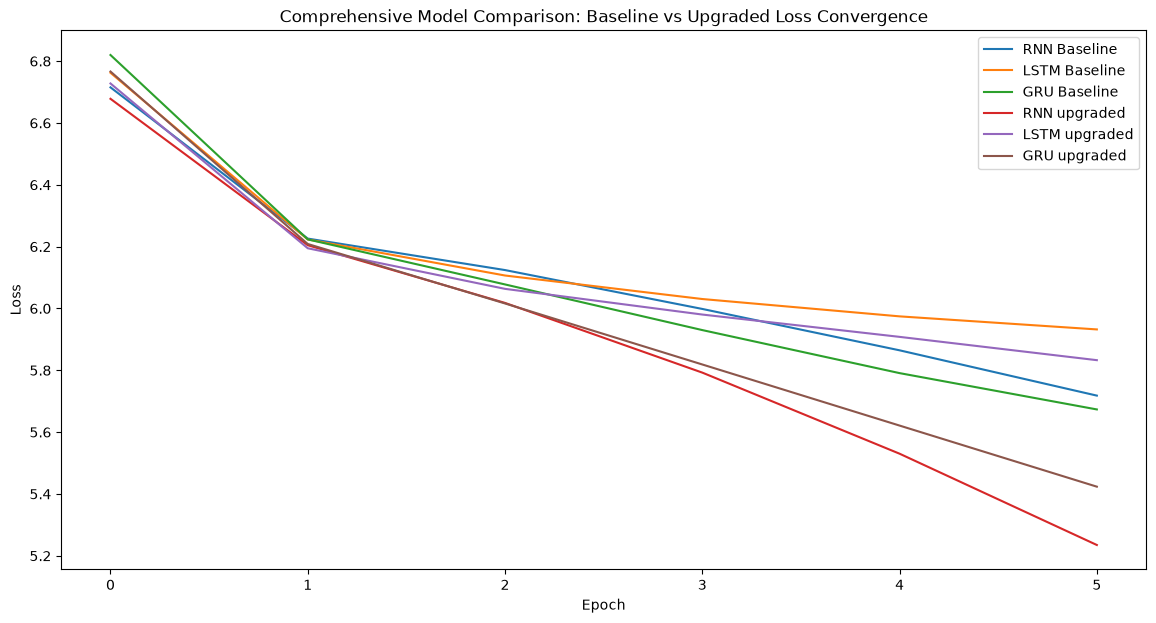

In [12]:
plt.figure(figsize=(14,7))
plt.plot(history_rnn_base.history['loss'], label='RNN Baseline')
plt.plot(history_lstm_base.history['loss'], label='LSTM Baseline')
plt.plot(history_gru_base.history['loss'], label='GRU Baseline')
plt.plot(history_rnn_upgraded.history['loss'], label='RNN upgraded')
plt.plot(history_lstm_upgraded.history['loss'], label='LSTM upgraded')
plt.plot(history_gru_upgraded.history['loss'], label='GRU upgraded')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comprehensive Model Comparison: Baseline vs Upgraded Loss Convergence")
plt.legend()
plt.show()

In [13]:
training_times = {
    "RNN Base": rnn_base_training_time,
    "RNN Upgraded": rnn_upgraded_training_time,
    "LSTM Base": lstm_base_training_time,
    "LSTM Upgraded": lstm_upgraded_training_time,
    "GRU Base": gru_base_training_time,
    "GRU Upgraded": gru_upgraded_training_time,
}

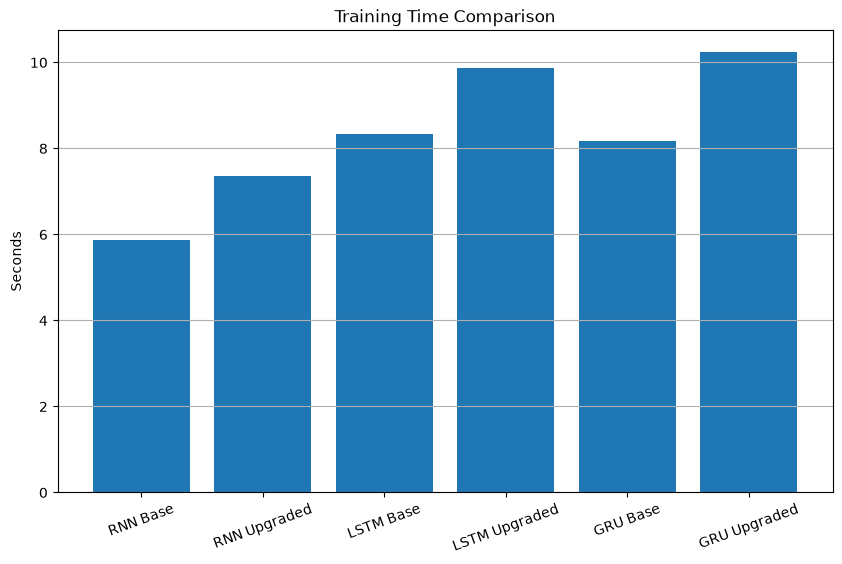

In [14]:
plt.figure(figsize=(10,6))

plt.bar(training_times.keys(), training_times.values())

plt.xticks(rotation=20)
plt.ylabel("Seconds")
plt.title("Training Time Comparison")
plt.grid(axis="y")

plt.show()

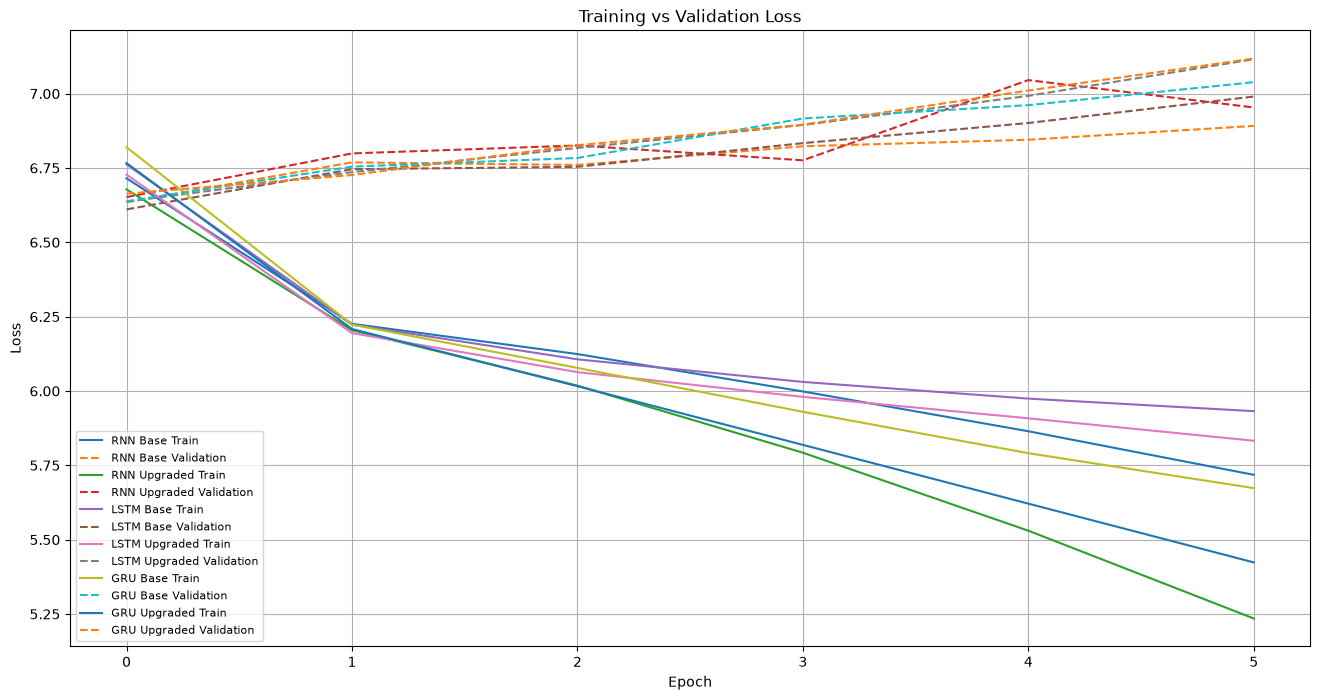

In [15]:
plt.figure(figsize=(16,8))

histories = {
    "RNN Base": history_rnn_base,
    "RNN Upgraded": history_rnn_upgraded,
    "LSTM Base": history_lstm_base,
    "LSTM Upgraded": history_lstm_upgraded,
    "GRU Base": history_gru_base,
    "GRU Upgraded": history_gru_upgraded
}

for name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{name} Train")
    plt.plot(history.history["val_loss"], linestyle="--", label=f"{name} Validation")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

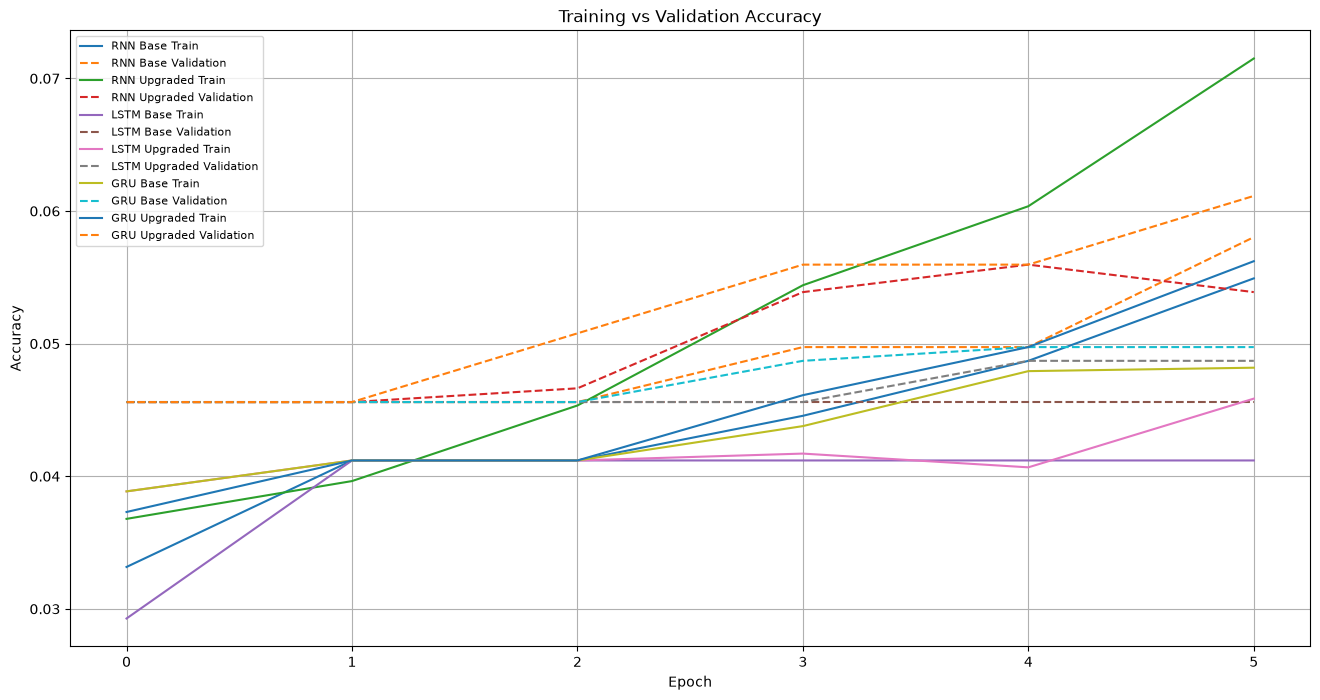

In [16]:
plt.figure(figsize=(16,8))

for name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{name} Train")
    plt.plot(history.history["val_accuracy"], linestyle="--", label=f"{name} Validation")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

In [17]:
parameter_counts = {
    "RNN Base": rnn_baseline.count_params(),
    "RNN Upgraded": rnn_upgraded.count_params(),
    "LSTM Base": lstm_baseline.count_params(),
    "LSTM Upgraded": lstm_upgraded.count_params(),
    "GRU Base": gru_baseline.count_params(),
    "GRU Upgraded": gru_upgraded.count_params()
}

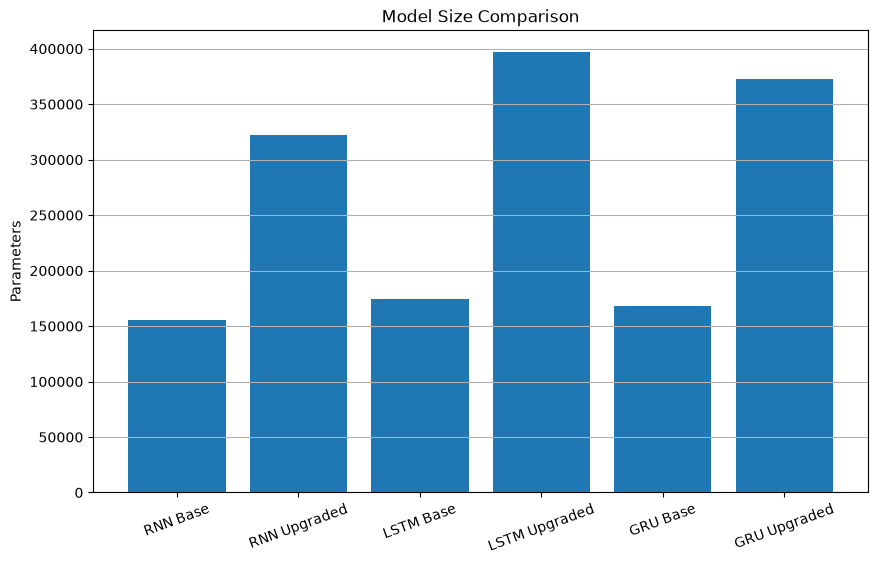

In [18]:
plt.figure(figsize=(10,6))

plt.bar(parameter_counts.keys(), parameter_counts.values())

plt.xticks(rotation=20)
plt.ylabel("Parameters")
plt.title("Model Size Comparison")
plt.grid(axis="y")

plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [19]:
def generate_text_argmax(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

        # Always pick the highest probability token (Greedy Search)
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [20]:
def generate_text_temperature(model, seed_text, next_words=5, temperature=0.7):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

        preds = model.predict(token_list, verbose=0)[0]
        preds = np.log(preds + 1e-7) / temperature
        exp_preds = np.exp(preds)
        predicted_probs = exp_preds / np.sum(exp_preds)

        predicted = np.random.choice(len(predicted_probs), p=predicted_probs)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [21]:
print("RNN :", generate_text_argmax(rnn_baseline, "thou art", 5))
print("LSTM:", generate_text_argmax(lstm_baseline, "thou art", 5))
print("GRU :", generate_text_argmax(gru_baseline, "thou art", 5))

RNN : thou art the the the the the
LSTM: thou art the the the the the
GRU : thou art the the the the the


In [22]:
print("RNN :", generate_text_argmax(rnn_baseline, "thou art", 10))
print("LSTM:", generate_text_argmax(lstm_baseline, "thou art", 10))
print("GRU :", generate_text_argmax(gru_baseline, "thou art", 10))

RNN : thou art the the the the the the the the the the
LSTM: thou art the the the the the the the the the the
GRU : thou art the the the the the the the the the the


In [23]:
print("RNN :", generate_text_temperature(rnn_baseline, "thou art", 5, temperature=0.7))
print("LSTM:", generate_text_temperature(lstm_baseline, "thou art", 5, temperature=0.7))
print("GRU :", generate_text_temperature(gru_baseline, "thou art", 5, temperature=0.7))

RNN : thou art the sent the good those
LSTM: thou art citizen with you shall but
GRU : thou art fully when take on't steel


In [24]:
print("RNN :", generate_text_temperature(rnn_baseline, "thou art", 10, temperature=0.7))
print("LSTM:", generate_text_temperature(lstm_baseline, "thou art", 10, temperature=0.7))
print("GRU :", generate_text_temperature(gru_baseline, "thou art", 10, temperature=0.7))

RNN : thou art as modest wisdoms you man not rest side but the
LSTM: thou art upon in on wars sell and their you to a
GRU : thou art my the acclamations restrain i i none in your leg


In [25]:
models_list = [
    rnn_baseline,
    rnn_upgraded,
    lstm_baseline,
    lstm_upgraded,
    gru_baseline,
    gru_upgraded,
]
histories_list = [
    history_rnn_base,
    history_rnn_upgraded,
    history_lstm_base,
    history_lstm_upgraded,
    history_gru_base,
    history_gru_upgraded,
]
model_names = [
    "RNN Baseline",
    "RNN Upgraded",
    "LSTM Baseline",
    "LSTM Upgraded",
    "GRU Baseline",
    "GRU Upgraded",
]

for i in range(len(models_list)):
    name = model_names[i]
    model = models_list[i]
    history = histories_list[i]

    print("\n=============================================")
    print("MODEL:", name)
    print("=============================================")

    final_loss = history.history["loss"][-1]
    print("1. Final Training Loss:", round(final_loss, 4))

    total_params = model.count_params()
    print("2. Memory Footprint (Total Params):", total_params)
    print("-" * 45)

    generated_output_argmax = generate_text_argmax(model, "thou art", next_words=10)
    print("3. [ARGMAX] Generated Text (10 words):", generated_output_argmax)

    words = generated_output_argmax.lower().split()
    if len(set(words)) < len(words):
        print("-> Quality Note: Model is repeating words in a loop.")
    else:
        print("-> Quality Note: Text has unique words.")

    if any(w in generated_output_argmax.lower() for w in ["thou", "thee", "love", "shall"]):
        print("4. Long-Term Dependency: Passed")
    else:
        print("4. Long-Term Dependency: Failed/Weak")

    print("-" * 45)

    generated_output_temparature = generate_text_temperature(model, "thou art", next_words=10, temperature=0.7)
    print("5. [TEMPERATURE] Generated Text (10 words):", generated_output_temparature)

    words = generated_output_temparature.lower().split()
    if len(set(words)) < len(words):
        print("-> Quality Note: Model is repeating words in a loop.")
    else:
        print("-> Quality Note: Text has unique words.")

    if any(w in generated_output_temparature.lower() for w in ["thou", "thee", "love", "shall"]):
        print("6. Long-Term Dependency: Passed")
    else:
        print("6. Long-Term Dependency: Failed/Weak")


MODEL: RNN Baseline
1. Final Training Loss: 5.7181
2. Memory Footprint (Total Params): 155879
---------------------------------------------
3. [ARGMAX] Generated Text (10 words): thou art the the the the the the the the the the
-> Quality Note: Model is repeating words in a loop.
4. Long-Term Dependency: Passed
---------------------------------------------
5. [TEMPERATURE] Generated Text (10 words): thou art his thou less and and veins of the is lartius
-> Quality Note: Model is repeating words in a loop.
6. Long-Term Dependency: Passed

MODEL: RNN Upgraded
1. Final Training Loss: 5.2349
2. Memory Footprint (Total Params): 322503
---------------------------------------------
3. [ARGMAX] Generated Text (10 words): thou art the the the the the the the the the the
-> Quality Note: Model is repeating words in a loop.
4. Long-Term Dependency: Passed
---------------------------------------------
5. [TEMPERATURE] Generated Text (10 words): thou art your greatness our distribution the but tit

In [26]:
comparison_data = []

models = {
    "RNN Base": (rnn_baseline, history_rnn_base, rnn_base_training_time),
    "RNN Upgraded": (rnn_upgraded, history_rnn_upgraded, rnn_upgraded_training_time),
    "LSTM Base": (lstm_baseline, history_lstm_base, lstm_base_training_time),
    "LSTM Upgraded": (lstm_upgraded, history_lstm_upgraded, lstm_upgraded_training_time),
    "GRU Base": (gru_baseline, history_gru_base, gru_base_training_time),
    "GRU Upgraded": (gru_upgraded, history_gru_upgraded, gru_upgraded_training_time),
}

for name, (model, history, train_time) in models.items():

    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]

    perplexity = np.exp(val_loss)
    params = model.count_params()
    memory_mb = params * 4 / (1024**2)

    comparison_data.append({
        "Model": name,
        "Train Loss": round(train_loss,4),
        "Val Loss": round(val_loss,4),
        "Train Accuracy": round(train_acc,4),
        "Val Accuracy": round(val_acc,4),
        "Perplexity": round(perplexity,2),
        "Parameters": params,
        "Memory (MB)": round(memory_mb, 2),
        "Training Time (s)": round(train_time,2)
    })

comparison_df = pd.DataFrame(comparison_data)

comparison_df = comparison_df.sort_values("Val Loss")

print(comparison_df.to_string(index=False))

comparison_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

best_accuracy = comparison_df.loc[
    comparison_df["Val Accuracy"].idxmax()
]

print("Best Validation Accuracy")
print(best_accuracy)

best_loss = comparison_df.loc[
    comparison_df["Val Loss"].idxmin()
]

print("Lowest Validation Loss")
print(best_loss)

        Model  Train Loss  Val Loss  Train Accuracy  Val Accuracy  Perplexity  Parameters  Memory (MB)  Training Time (s)
     RNN Base      5.7181    6.8915          0.0549        0.0580      983.88      155879         0.59               5.88
 RNN Upgraded      5.2349    6.9535          0.0715        0.0539     1046.83      322503         1.23               7.37
    LSTM Base      5.9322    6.9903          0.0412        0.0456     1086.01      174503         0.67               8.33
     GRU Base      5.6734    7.0385          0.0482        0.0497     1139.72      168487         0.64               8.18
LSTM Upgraded      5.8328    7.1157          0.0459        0.0487     1231.14      396615         1.51               9.87
 GRU Upgraded      5.4236    7.1182          0.0562        0.0611     1234.19      372295         1.42              10.23
Best Validation Accuracy
Model                GRU Upgraded
Train Loss                 5.4236
Val Loss                   7.1182
Train Accuracy     

In [27]:
def evaluate_generated_text(text):
    words = text.lower().split()

    total_words = len(words)

    unique_words = len(set(words))

    unique_ratio = unique_words / total_words if total_words else 0

    repetition_rate = 1 - unique_ratio

    avg_word_length = (
        sum(len(word) for word in words) / total_words
        if total_words else 0
    )

    return {
        "Generated Text": text,
        "Total Words": total_words,
        "Unique Words": unique_words,
        "Unique Ratio": round(unique_ratio, 3),
        "Repetition Rate": round(repetition_rate, 3),
        "Average Word Length": round(avg_word_length, 2)
    }

In [28]:
generated_texts = {}

for name, (model, _, _) in models.items():

    generated_texts[name] = generate_text_temperature(
        model,
        "thou art",
        next_words=20,
        temperature=0.7
    )

In [29]:
evaluation_results = []

for name, text in generated_texts.items():

    metrics = evaluate_generated_text(text)

    metrics["Model"] = name

    evaluation_results.append(metrics)

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Generated Text,Total Words,Unique Words,Unique Ratio,Repetition Rate,Average Word Length,Model
0,thou art they him though arms what your what t...,22,18,0.818,0.182,3.64,RNN Base
1,thou art he but might with take to they by blo...,22,21,0.955,0.045,3.27,RNN Upgraded
2,thou art more have from in battle up to us and...,22,21,0.955,0.045,3.64,LSTM Base
3,thou art it them and the seeking you great inc...,22,17,0.773,0.227,3.55,LSTM Upgraded
4,thou art get and else and who where ho open ha...,22,20,0.909,0.091,4.41,GRU Base
5,thou art clubs general's garners a done themse...,22,22,1.000,0.000,4.95,GRU Upgraded


In [30]:
pd.set_option("display.max_colwidth", None)

evaluation_df[
    [
        "Model",
        "Generated Text",
        "Unique Ratio",
        "Repetition Rate"
    ]
]

,Model,Generated Text,Unique Ratio,Repetition Rate
0,RNN Base,thou art they him though arms what your what the and upon the outweighs of them to the it me thus the,0.818,0.182
1,RNN Upgraded,thou art he but might with take to they by bloody make the and his you do not you run knows a,0.955,0.045
2,LSTM Base,thou art more have from in battle up to us and on hear not what in flatter i honours shrug you places,0.955,0.045
3,LSTM Upgraded,thou art it them and the seeking you great incensed i with and for it than souls i first the the by,0.773,0.227
4,GRU Base,thou art get and else and who where ho open have like overta'en people deserving tell eleven the might above puts tell,0.909,0.091
5,GRU Upgraded,thou art clubs general's garners a done themselves say select work's there's fly how together have hunger wish those home corn sun,1.000,0.000


In [31]:
evaluation_df.to_csv(
    "generated_text_evaluation.csv",
    index=False
)

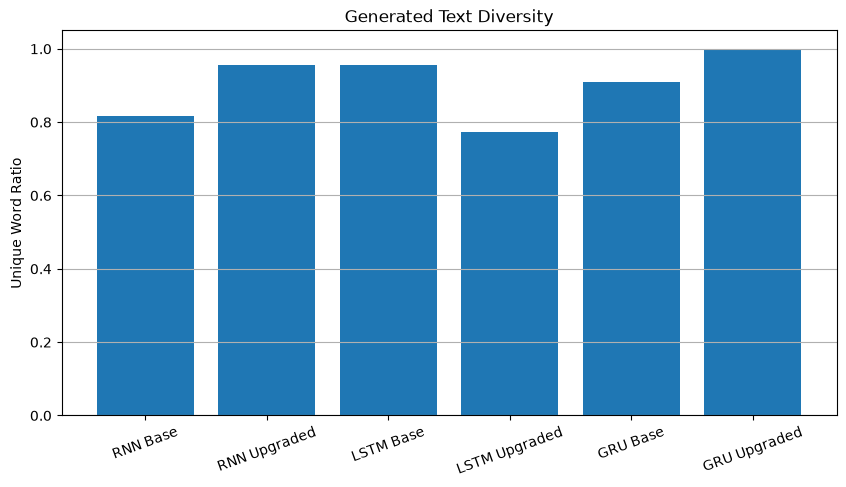

In [32]:
plt.figure(figsize=(10,5))

plt.bar(
    evaluation_df["Model"],
    evaluation_df["Unique Ratio"]
)

plt.xticks(rotation=20)

plt.ylabel("Unique Word Ratio")

plt.title("Generated Text Diversity")

plt.grid(axis="y")

plt.show()

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**